# Proyecto Etapa 1 — Clasificación de sentimiento en reseñas 
**ISIS-2611 Aprendizaje de Máquina · 2026-20 · Grupo: Danna García - 202320823,**

**Problema:** dado el texto de una reseña en español, predecir si el sentimiento global es `negativo`, `neutral` o `positivo`.

**Métrica de Kaggle:** exactitud (*accuracy*).

**Restricciones:** solo scikit-learn, representaciones clásicas (BoW, TF-IDF, n-gramas). Nada de redes neuronales ni embeddings preentrenados.

**Estructura del cuaderno**
1. Carga y exploración de los datos
2. Preprocesamiento del texto
3. Partición entrenamiento / validación
4. Iteraciones (cada una = un envío a Kaggle)
5. Comparación de iteraciones
6. Evaluación del mejor modelo
7. Interpretación del modelo
8. Modelo final, archivo de envío y `joblib`
9. Conclusiones y limitaciones

## 0. Librerías y configuración

In [4]:
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)

SEED = 42
os.makedirs('submissions', exist_ok=True)

## 1. Carga y exploración de los datos

In [5]:
train = pd.read_csv('data/train.csv')
eval_df = pd.read_csv('data/eval.csv')

print('Entrenamiento:', train.shape)
print('Evaluación:   ', eval_df.shape)
train.head()

Entrenamiento: (12000, 3)
Evaluación:    (3000, 2)


,id,text,label
0,0,Lo pedí un martes por la noche y me llegó al d...,neutral
1,1,Se lo compré a un familiar después de pensarla...,positivo
2,2,Lo pedí a mediados de mes y me llegó en tres d...,negativo
3,3,Compré esto en línea y llegó en unos tres días...,negativo
4,4,Compré este kit el mes pasado porque necesitab...,positivo


In [6]:
# Calidad de los datos
print('Valores nulos por columna:')
print(train.isna().sum(), '\n')
print('Reseñas duplicadas en entrenamiento:', train['text'].duplicated().sum())
print('Reseñas de entrenamiento repetidas en evaluación:', train['text'].isin(eval_df['text']).sum())

Valores nulos por columna:
id       0
text     0
label    0
dtype: int64 

Reseñas duplicadas en entrenamiento: 0
Reseñas de entrenamiento repetidas en evaluación: 0


No hay valores nulos, duplicados ni reseñas compartidas entre entrenamiento y evaluación, por lo que no se requiere eliminar registros.

,cantidad,porcentaje
label,,
positivo,4212,35.1
negativo,4212,35.1
neutral,3576,29.8


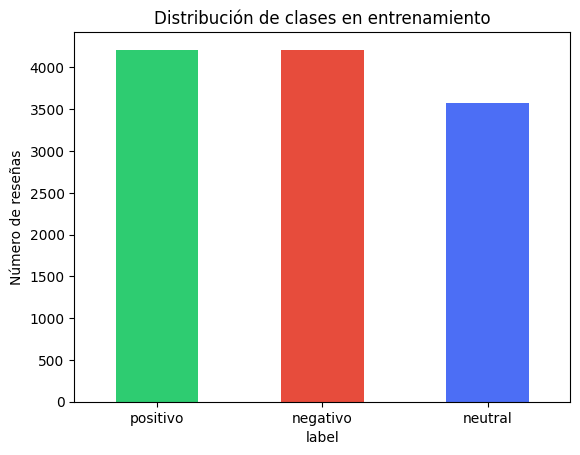

In [7]:
# Distribución de la variable objetivo
conteo = train['label'].value_counts()
porcentaje = train['label'].value_counts(normalize=True).round(3) * 100
display(pd.DataFrame({'cantidad': conteo, 'porcentaje': porcentaje}))

conteo.plot(kind='bar', color=['#2ECC71', '#E74C3C', '#4C6EF5'])
plt.title('Distribución de clases en entrenamiento')
plt.ylabel('Número de reseñas')
plt.xticks(rotation=0)
plt.show()

Las clases `positivo` y `negativo` representan cada una el 35,1 % de los datos y `neutral` el 29,8 %. El desbalance es leve, por lo que:
- No se aplican técnicas de sobremuestreo como SMOTE: la diferencia entre clases no es suficiente para sesgar al modelo de forma importante.
- Toda partición de los datos se hace de forma estratificada para conservar estas proporciones.
- La exactitud (*accuracy*), métrica de la competencia, es adecuada. Como referencia, un modelo que siempre predice la clase mayoritaria obtendría 35,1 %.

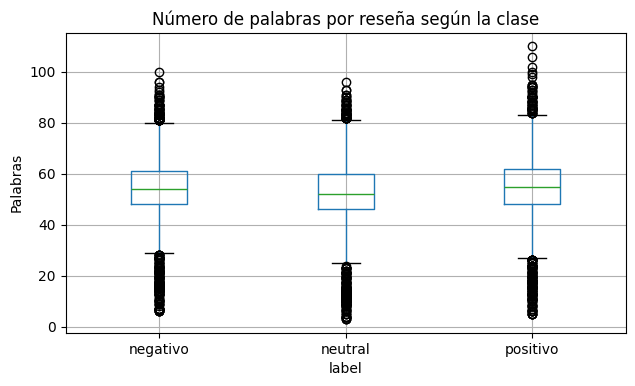

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
negativo,4212.0,54.2,12.7,6.0,48.0,54.0,61.0,100.0
neutral,3576.0,52.3,13.9,3.0,46.0,52.0,60.0,96.0
positivo,4212.0,55.0,13.0,5.0,48.0,55.0,62.0,110.0


In [8]:
# Longitud de las reseñas por clase
train['n_palabras'] = train['text'].str.split().str.len()

train.boxplot(column='n_palabras', by='label', figsize=(7, 4))
plt.suptitle('')
plt.title('Número de palabras por reseña según la clase')
plt.ylabel('Palabras')
plt.show()

train.groupby('label')['n_palabras'].describe().round(1)

Las tres clases tienen una longitud similar (alrededor de 53 palabras en promedio), así que la longitud del texto no aporta información para distinguir el sentimiento.

In [9]:
# Ejemplos de cada clase
for clase in ['negativo', 'neutral', 'positivo']:
    print('=====', clase.upper(), '=====')
    ejemplos = train[train['label'] == clase]['text'].sample(3, random_state=SEED)
    for texto in ejemplos:
        print('-', texto, '\n')

===== NEGATIVO =====
- La compré en noviembre en una oferta del buen fin, llegó en cuatro días. En pocas palabras, la cámara no es para nada lo que esperaba. La uso nomás para fotos casuales en casa. Además, la interfaz fue todo un acierto, la uso a diario y la dejo igual que cuando llegó. 

- Lo compre hace poco por internet porque queria reemplazar uno viejo que tenia en la casa. Me llego en unos trs dias. La autonoia me salio eficiente para lo que necesitaba, la uso a diario en las mananas. Eso si, el tamano es de mala calidad hasta ahora. 

- Llevo ya un rato con él, lo compré para usar en la cocina de mi casa y llegó en tres días. En mi opinión el material quedó sólido en general, se siente firme al tocarlo. La duración de la carga terminó siendo mal hecha desde el primer día, y eso que seguí las instrucciones de uso. 

===== NEUTRAL =====
- Lo pedí un martes por la tarde porque justo andaba cerca de la oficina donde lo iba a usar. Llegó en menos de tres días, o sea que el jueves 

In [10]:
# Proporción de reseñas que contienen al menos una tilde o ñ
print('Entrenamiento:', train['text'].str.contains('[áéíóúñ]').mean().round(3))
print('Evaluación:   ', eval_df['text'].str.contains('[áéíóúñ]').mean().round(3))

Entrenamiento: 0.687
Evaluación:    0.686


**Hallazgos de la exploración**
- La mayoría de reseñas mezcla aspectos positivos y negativos. Por ejemplo, *"el soporte técnico me resultó incumplidor (...) Al final de cuentas, la nitidez de la imagen se mantuvo decente"* está etiquetada como `positivo`.
- La opinión que define la clase suele estar al **final de la reseña** o después de **conectores contrastivos** y de conclusión como *pero*, *sin embargo*, *al final de cuentas* o *en pocas palabras*.
- En cambio, los comentarios introducidos con *además* o *de paso* suelen ser secundarios: hay reseñas `positivo` que terminan con una queja menor de este tipo.
- Las reseñas `neutral` describen la compra (envío, color, uso) sin emitir una opinión.
- Cerca del 31 % de las reseñas está escrito sin tildes ni ñ (*"llego"*, *"mananas"*), en la misma proporción en entrenamiento y en evaluación.

Estos hallazgos orientan el preprocesamiento (sección 2) y la construcción de características (sección 4).

## 2. Preprocesamiento del texto
Se define una función de limpieza con los pasos clásicos de preparación de texto. Los pasos de eliminación de stop words y stemming quedan como opciones (`True`/`False`) para medir su efecto antes de decidir si se usan.

| Paso | Qué hace |
|---|---|
| Minúsculas | *"Excelente"* y *"excelente"* pasan a ser el mismo término |
| Quitar tildes y ñ | *"llegó"* y *"llego"* pasan a ser el mismo término, porque el 31 % de las reseñas se escribió sin tildes |
| Quitar signos y números | Elimina caracteres que no aportan al sentimiento. Se conserva el punto porque marca el final de cada oración |
| Stop words (opcional) | Elimina palabras muy frecuentes como *el*, *de*, *que* |
| Stemming (opcional) | Reduce cada palabra a su raíz: *decepcionante* → *decepcion* |

In [11]:
TILDES = {'á': 'a', 'é': 'e', 'í': 'i', 'ó': 'o', 'ú': 'u', 'ü': 'u', 'ñ': 'n'}

def quitar_tildes(texto):
    for letra, reemplazo in TILDES.items():
        texto = texto.replace(letra, reemplazo)
    return texto

stop_es = {quitar_tildes(p) for p in stopwords.words('spanish')}
stemmer = SnowballStemmer('spanish')

def limpiar_texto(texto, quitar_stopwords=False, aplicar_stemming=False):
    # 1. Normalización
    texto = quitar_tildes(texto.lower())
    texto = re.sub(r'[^\w\s.]', ' ', texto)   # quita signos, excepto el punto
    texto = re.sub(r'\d+', ' ', texto)          # quita números
    texto = re.sub(r'\s+', ' ', texto).strip()  # une espacios repetidos
    # 2. Tokenización
    tokens = texto.split()
    # 3. Stop words
    if quitar_stopwords:
        tokens = [t for t in tokens if t.strip('.') not in stop_es]
    # 4. Stemming
    if aplicar_stemming:
        tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

ejemplo = train['text'][1]
print('ORIGINAL:  ', ejemplo)
print('LIMPIO:    ', limpiar_texto(ejemplo))
print('SIN STOP:  ', limpiar_texto(ejemplo, quitar_stopwords=True))
print('STEMMING:  ', limpiar_texto(ejemplo, aplicar_stemming=True))

ORIGINAL:   Se lo compré a un familiar después de pensarla varias semanas, llegó en unos cuatro días a mi casa. La verdad sea dicha, el soporte técnico me resultó incumplidor para lo que necesitaba, tardaban harto en contestar. Al final de cuentas, la nitidez de la imagen se mantuvo decente en el uso diario.
LIMPIO:     se lo compre a un familiar despues de pensarla varias semanas llego en unos cuatro dias a mi casa. la verdad sea dicha el soporte tecnico me resulto incumplidor para lo que necesitaba tardaban harto en contestar. al final de cuentas la nitidez de la imagen se mantuvo decente en el uso diario.
SIN STOP:   compre familiar despues pensarla varias semanas llego cuatro dias casa. verdad dicha soporte tecnico resulto incumplidor necesitaba tardaban harto contestar. final cuentas nitidez imagen mantuvo decente uso diario.
STEMMING:   se lo compr a un famili despu de pens vari seman lleg en unos cuatr dias a mi casa. la verd sea dich el soport tecnic me result incumplidor par l

In [12]:
# Stop words de la lista en español que cambian el sentido de una reseña
palabras_clave = ['no', 'pero', 'muy', 'sin', 'nada', 'mas', 'poco', 'ni']
print([p for p in palabras_clave if p in stop_es])

['no', 'pero', 'muy', 'sin', 'nada', 'mas', 'poco', 'ni']


La lista de stop words en español incluye *no*, *pero*, *muy*, *sin* y *nada*. Al eliminarlas, *"la cámara **no** es buena"* queda igual a *"la cámara es buena"*. Para comprobar con datos si conviene eliminarlas, se comparan las cuatro versiones de limpieza usando el mismo modelo de referencia (TF-IDF + regresión logística) y validación cruzada estratificada de 5 particiones. Así, la única diferencia entre filas es el preprocesamiento.

In [13]:
versiones = {
    'Texto original':            train['text'],
    'Limpieza básica':           train['text'].apply(limpiar_texto),
    'Limpieza + sin stop words': train['text'].apply(limpiar_texto, quitar_stopwords=True),
    'Limpieza + stemming':       train['text'].apply(limpiar_texto, aplicar_stemming=True),
}

modelo_referencia = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('modelo', LogisticRegression(max_iter=2000))
])
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

filas = []
for nombre, textos in versiones.items():
    puntajes = cross_val_score(modelo_referencia, textos, train['label'], cv=kfold, scoring='accuracy')
    vocabulario = len(CountVectorizer().fit(textos).vocabulary_)
    filas.append({'versión': nombre,
                  'palabras distintas': vocabulario,
                  'accuracy media': round(puntajes.mean(), 4),
                  'desviación estándar': round(puntajes.std(), 4)})

pd.DataFrame(filas)

,versión,palabras distintas,accuracy media,desviación estándar
0,Texto original,6035,0.7249,0.0033
1,Limpieza básica,5436,0.7273,0.0037
2,Limpieza + sin stop words,5286,0.7224,0.0058
3,Limpieza + stemming,5028,0.7278,0.0075


**Decisión:** se usa la **limpieza básica**, sin eliminar stop words y sin stemming.
- La limpieza básica mejora la exactitud frente al texto original (0,7249 → 0,7273) y reduce el vocabulario de 6.035 a 5.436 palabras distintas, porque une variantes de una misma palabra.
- Eliminar stop words obtiene la menor exactitud (0,7224): confirma que palabras como *no* o *pero* son necesarias para detectar el sentimiento.
- El stemming obtiene 0,7279, una diferencia de 0,0006 frente a la limpieza básica. Esa diferencia es mucho menor que la desviación estándar entre particiones (≈0,007), así que no es una mejora real. Se prefiere la opción más simple, que además conserva palabras completas y legibles.

La columna `texto_limpio` se crea con esta limpieza y es la que reciben todos los modelos.

In [14]:
train['texto_limpio'] = train['text'].apply(limpiar_texto)
eval_df['texto_limpio'] = eval_df['text'].apply(limpiar_texto)
train[['text', 'texto_limpio']].head(3)

,text,texto_limpio
0,Lo pedí un martes por la noche y me llegó al d...,lo pedi un martes por la noche y me llego al d...
1,Se lo compré a un familiar después de pensarla...,se lo compre a un familiar despues de pensarla...
2,Lo pedí a mediados de mes y me llegó en tres d...,lo pedi a mediados de mes y me llego en tres d...


## 3. Partición entrenamiento / validación
El archivo `eval.csv` no tiene etiquetas, por lo que no permite medir el desempeño localmente. Se reserva el 20 % de `train.csv` como conjunto de **validación**, de forma estratificada y con semilla fija para que los resultados sean replicables.

Cada modelo se entrena con el 80 % restante y se mide sobre validación. Esto permite comparar modelos sin depender del puntaje público de Kaggle, que se calcula con solo el 30 % de los datos de evaluación y tiene un número limitado de envíos.

In [15]:
X = train['texto_limpio']
y = train['label']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

print('Entrenamiento:', X_train.shape, '| Validación:', X_val.shape)
pd.DataFrame({'entrenamiento': y_train.value_counts(normalize=True).round(3),
              'validación': y_val.value_counts(normalize=True).round(3)})

Entrenamiento: (9600,) | Validación: (2400,)


,entrenamiento,validación
label,,
negativo,0.351,0.351
neutral,0.298,0.298
positivo,0.351,0.351


Las proporciones de cada clase se mantienen iguales en ambos conjuntos gracias a la estratificación.

### Función de evaluación y generación de envíos
Todos los modelos de la sección 4 se evalúan con la misma función, que:
1. Entrena el modelo con el conjunto de entrenamiento y calcula la exactitud en entrenamiento y en validación.
2. Registra el resultado en la tabla `resultados`, usada en la sección 5 para comparar los modelos.
3. Reentrena el modelo con **todo** `train.csv` y genera el archivo de envío para Kaggle en la carpeta `submissions/`.

Comparar la exactitud de entrenamiento con la de validación permite detectar sobreajuste: una diferencia grande indica que el modelo memoriza los datos de entrenamiento en lugar de generalizar.

In [16]:
resultados = []

def evaluar_y_enviar(nombre, modelo, descripcion):
    # 1. Entrenar con el 80 % y medir
    modelo.fit(X_train, y_train)
    acc_train = accuracy_score(y_train, modelo.predict(X_train))
    acc_val = accuracy_score(y_val, modelo.predict(X_val))
    print(f'{nombre} | accuracy entrenamiento: {acc_train:.4f} | validación: {acc_val:.4f}')

    # 2. Registrar el resultado
    resultados.append({'envío': nombre, 'cambio': descripcion,
                       'accuracy entrenamiento': round(acc_train, 4),
                       'accuracy validación': round(acc_val, 4)})

    # 3. Reentrenar con todos los datos y generar el archivo para Kaggle
    modelo.fit(X, y)
    envio = pd.DataFrame({'id': eval_df['id'],
                          'answer': modelo.predict(eval_df['texto_limpio'])})
    envio.to_csv(f'submissions/{nombre}.csv', index=False)
    print(f'Archivo generado: submissions/{nombre}.csv ({len(envio)} filas)')
    return modelo

## 4. Modelos

### Envío 1 — Bolsa de palabras + Naive Bayes

Partimos de una bolsa de palabras como enfoque inicial para clasificar las reseñas en negativo, neutral o positivo. Usamos `CountVectorizer` con unigramas para representar cada reseña mediante conteos de palabras y un clasificador Naive Bayes multinomial con `alpha=1.0`. Este modelo estima la distribución de los términos en cada clase y supone independencia condicional entre ellos dada la clase. El suavizado evita probabilidades nulas cuando una palabra no aparece en los ejemplos de una clase.

Para evaluar el modelo usamos la limpieza básica y la partición estratificada de 9.600 reseñas de entrenamiento y 2.400 de validación, con semilla 42. También realizamos validación cruzada estratificada de cinco particiones sobre el conjunto de entrenamiento, aprendiendo el vocabulario únicamente con los datos de entrenamiento de cada partición. Obtuvimos una exactitud media de 70,49 % en validación cruzada, con una desviación de 1,37 puntos porcentuales, y una exactitud de 81,99 % en entrenamiento y 71,08 % en validación. Como la limpieza se seleccionó previamente usando todas las reseñas etiquetadas, esta validación es una estimación local y no una evaluación completamente independiente del preprocesamiento.

La diferencia de aproximadamente 10,91 puntos entre entrenamiento y validación indica sobreajuste, por lo que el suavizado no es suficiente para eliminarlo. Además, los conteos no conservan el orden de las palabras ni distinguen dónde aparece una opinión dentro de la reseña. Esto puede dificultar la clasificación de negaciones y textos que mezclan elogios y críticas. Tomamos estos resultados como referencia para los siguientes experimentos. Después de la evaluación, reentrenamos el modelo con las 12.000 reseñas disponibles y generamos `submissions/envio1.csv`.

In [14]:
from sklearn.naive_bayes import MultinomialNB

cv_envios = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
modelo_envio1 = Pipeline([
    ('conteos', CountVectorizer(ngram_range=(1, 1))),
    ('modelo', MultinomialNB(alpha=1.0))
])
print('CV sobre entrenamiento: bolsa de palabras + Naive Bayes multinomial')
puntajes_envio1 = cross_val_score(
    modelo_envio1, X_train, y_train, cv=cv_envios,
    scoring='accuracy', error_score='raise'
)
print(f'Accuracy CV media: {puntajes_envio1.mean():.4f} | desviación: {puntajes_envio1.std():.4f}')
modelo_envio1 = evaluar_y_enviar(
    'envio1', modelo_envio1,
    'Bolsa de palabras con unigramas + Naive Bayes multinomial; alpha=1.0'
)
resultado_envio1 = resultados[-1].copy()
print(f'Características del modelo reentrenado: {len(modelo_envio1.named_steps["conteos"].vocabulary_)}')

CV sobre entrenamiento: bolsa de palabras + Naive Bayes multinomial


Accuracy CV media: 0.7049 | desviación: 0.0137


envio1 | accuracy entrenamiento: 0.8199 | validación: 0.7108
Archivo generado: submissions/envio1.csv (3000 filas)
Características del modelo reentrenado: 5436


### Envío 2 — TF-IDF + Regresión logística

Para mejorar el enfoque inicial, reemplazamos los conteos por una representación TF-IDF y el clasificador Naive Bayes por regresión logística. TF-IDF pondera cada palabra según su frecuencia en la reseña y su rareza en el conjunto de documentos; la regresión logística aprende coeficientes para distinguir las tres clases. Usamos unigramas, regularización L2 con `C=1.0`, un máximo de 2.000 iteraciones y semilla 42. Conservamos la limpieza y el procedimiento de evaluación del envío anterior, sin ajustar hiperparámetros con el conjunto de validación.

La exactitud media en validación cruzada fue de 72,51 %, con una desviación de 1,20 puntos porcentuales. En entrenamiento obtuvimos 83,46 % y en validación 73,88 %. Frente al envío 1, esto representa una mejora aproximada de 2,02 puntos en validación cruzada y 2,80 puntos en validación. Como cambiamos tanto la representación como el clasificador, esta comparación muestra una mejora del enfoque completo, pero no permite atribuirla por separado a TF-IDF o a la regresión logística.

La brecha entre entrenamiento y validación se reduce a aproximadamente 9,58 puntos, aunque sigue habiendo señales de sobreajuste. Los unigramas tampoco representan expresiones como *no funciona* de manera conjunta, ni distinguen la posición de la opinión principal. Estas dificultades motivan los siguientes cambios en la representación del texto. Una vez evaluado, reentrenamos el modelo con todas las reseñas etiquetadas y generamos `submissions/envio2.csv`.

In [15]:
from sklearn.exceptions import ConvergenceWarning

modelo_envio2 = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 1))),
    ('modelo', LogisticRegression(C=1.0, max_iter=2000, random_state=SEED))
])
with warnings.catch_warnings():
    warnings.simplefilter('error', ConvergenceWarning)
    print('CV sobre entrenamiento: TF-IDF con unigramas + regresión logística')
    puntajes_envio2 = cross_val_score(
        modelo_envio2, X_train, y_train, cv=cv_envios,
        scoring='accuracy', error_score='raise'
    )
    print(f'Accuracy CV media: {puntajes_envio2.mean():.4f} | desviación: {puntajes_envio2.std():.4f}')
    modelo_envio2 = evaluar_y_enviar(
        'envio2', modelo_envio2,
        'TF-IDF con unigramas + regresión logística; C=1.0'
    )
resultado_envio2 = resultados[-1].copy()
diferencia_cv_envio2 = puntajes_envio2.mean() - puntajes_envio1.mean()
diferencia_val_envio2 = (resultado_envio2['accuracy validación']
                          - resultado_envio1['accuracy validación'])
print(f'Cambio medio en CV frente al envío 1: {100 * diferencia_cv_envio2:+.2f} puntos porcentuales')
print(f'Cambio en validación frente al envío 1: {100 * diferencia_val_envio2:+.2f} puntos porcentuales')
print(f'Características del modelo reentrenado: {len(modelo_envio2.named_steps["tfidf"].vocabulary_)}')

CV sobre entrenamiento: TF-IDF con unigramas + regresión logística


Accuracy CV media: 0.7251 | desviación: 0.0120


envio2 | accuracy entrenamiento: 0.8346 | validación: 0.7388


Archivo generado: submissions/envio2.csv (3000 filas)
Cambio medio en CV frente al envío 1: +2.02 puntos porcentuales
Cambio en validación frente al envío 1: +2.80 puntos porcentuales
Características del modelo reentrenado: 5436


### Envío 5 — Conectores contrastivos + búsqueda de hiperparámetros

## 5. Comparación de envíos

## 6. Evaluación del mejor modelo

## 7. Modelo final y conclusiones